# 0. Dodanie ścieżek do datasetu

In [9]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import seaborn as sns

    HAS_SEABORN = True
    sns.set_theme(style="whitegrid")
except ImportError:
    HAS_SEABORN = False

sys.path.append(str(Path("..").resolve() / "src"))

from config.config import setup

cfg = setup()

HAR_ROOT = cfg["HAR_ROOT"]
FIGURES_DIR = cfg["FIGURES_DIR"]
RANDOM_STATE = cfg["RANDOM_STATE"]

# 1. Załadowanie danych z datasetu

In [10]:
def _fix_duplicate_feature_names(names):
    seen, out = {}, []
    for n in names:
        if n in seen:
            seen[n] += 1
            out.append(f"{n}__{seen[n]}")
        else:
            seen[n] = 0
            out.append(n)
    return out


def load_har_data():
    har_root: Path | None = None

    if har_root is None:
        har_root = HAR_ROOT
    features = pd.read_csv(
        har_root / "features.txt", sep=r"\s+", header=None, names=["idx", "name"]
    )
    feature_names = _fix_duplicate_feature_names(features["name"].tolist())

    activities = pd.read_csv(
        har_root / "activity_labels.txt", sep=r"\s+", header=None, names=["id", "label"]
    )
    activity_map = dict(zip(activities["id"], activities["label"]))

    X_train = pd.read_csv(
        har_root / "train" / "X_train.txt", sep=r"\s+", header=None, names=feature_names
    )
    y_train = pd.read_csv(
        har_root / "train" / "y_train.txt",
        sep=r"\s+",
        header=None,
        names=["activity_id"],
    )["activity_id"]
    y_train = y_train.map(activity_map).astype("category")
    groups_train = pd.read_csv(
        har_root / "train" / "subject_train.txt",
        sep=r"\s+",
        header=None,
        names=["subject"],
    )["subject"]

    X_test = pd.read_csv(
        har_root / "test" / "X_test.txt", sep=r"\s+", header=None, names=feature_names
    )
    y_test = pd.read_csv(
        har_root / "test" / "y_test.txt", sep=r"\s+", header=None, names=["activity_id"]
    )["activity_id"]
    y_test = y_test.map(activity_map).astype("category")
    groups_test = pd.read_csv(
        har_root / "test" / "subject_test.txt",
        sep=r"\s+",
        header=None,
        names=["subject"],
    )["subject"]

    return X_train, y_train, groups_train, X_test, y_test, groups_test, feature_names


X_train, y_train, groups_train, X_test, y_test, groups_test, feature_names = (
    load_har_data()
)

print(
    f"X_train: {X_train.shape} | y_train: {y_train.shape} | osoby w train: {groups_train.nunique()}"
)
print(
    f"X_test : {X_test.shape}  | y_test : {y_test.shape}  | osoby w test : {groups_test.nunique()}"
)
print(f"Liczba cech: {len(feature_names)}")
print(f"Klasy: {list(y_train.cat.categories)}")

X_train: (7352, 561) | y_train: (7352,) | osoby w train: 21
X_test : (2947, 561)  | y_test : (2947,)  | osoby w test : 9
Liczba cech: 561
Klasy: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


# 2. Sprawdzenie danych

In [11]:
assert X_train.shape[1] == 561, "Powinno być 561 cech."
assert X_train.shape[0] == y_train.shape[0] == groups_train.shape[0]
assert X_test.shape[0] == y_test.shape[0] == groups_test.shape[0]

print(f"NaN w X_train (oczekiwane 0): \t{int(X_train.isna().sum().sum())}")
print(f"NaN w X_test (oczekiwane 0): \t{int(X_test.isna().sum().sum())}")
print(
    f"\nZakres X_train (oczekiwany: [-1, 1]): \t[{X_train.values.min():.4f}, {X_train.values.max():.4f}]"
)
print(
    f"Zakres X_test (oczekiwany: [-1, 1]): \t[{X_test.values.min():.4f}, {X_test.values.max():.4f}]"
)

train_subjects = set(groups_train.unique())
test_subjects = set(groups_test.unique())
print(
    f"\nIds osób w train ({len(train_subjects)}): \t\t{sorted(int(x) for x in train_subjects)}"
)
print(
    f"Ids osób w w test  ({len(test_subjects)}): \t{sorted(int(x) for x in test_subjects)}"
)
print(
    f"Część wspólna (powinna być pusta, ponieważ osoba o tym samym id nie powinna być w danych treningowych i testowych): {train_subjects & test_subjects}"
)

NaN w X_train (oczekiwane 0): 	0
NaN w X_test (oczekiwane 0): 	0

Zakres X_train (oczekiwany: [-1, 1]): 	[-1.0000, 1.0000]
Zakres X_test (oczekiwany: [-1, 1]): 	[-1.0000, 1.0000]

Ids osób w train (21): 		[1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]
Ids osób w w test  (9): 	[2, 4, 9, 10, 12, 13, 18, 20, 24]
Część wspólna (powinna być pusta, ponieważ osoba o tym samym id nie powinna być w danych treningowych i testowych): set()


# 3. Rozkład klas w train i test

                    train_n  train_%  test_n  test_%
activity_id                                         
LAYING               1407.0    19.14   537.0   18.22
SITTING              1286.0    17.49   491.0   16.66
STANDING             1374.0    18.69   532.0   18.05
WALKING              1226.0    16.68   496.0   16.83
WALKING_DOWNSTAIRS    986.0    13.41   420.0   14.25
WALKING_UPSTAIRS     1073.0    14.59   471.0   15.98
SUMA                 7352.0   100.00  2947.0   99.99

Balans klas - ratio max/min (train): 1.43
Balans klas - ratio max/min (test) : 1.28


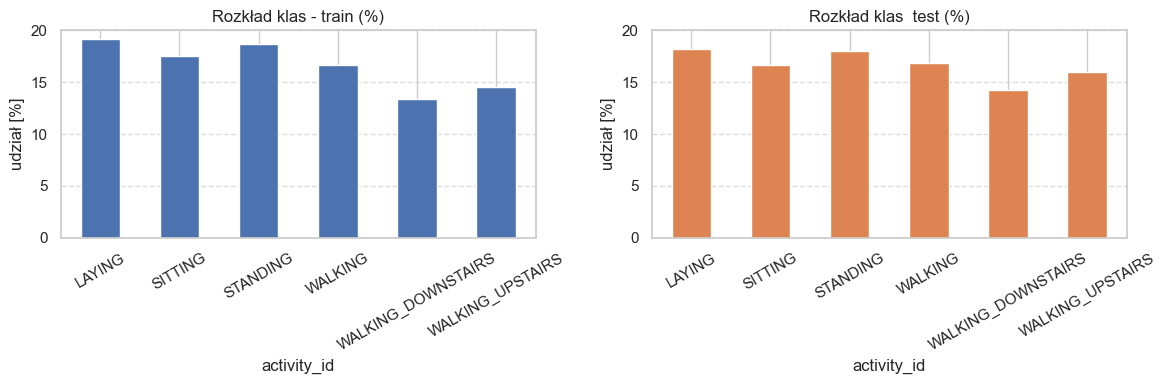

In [12]:
from matplotlib import pyplot as plt
import math


def class_dist(y, name):
    counts = y.value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({f"{name}_n": counts, f"{name}_%": pct})


dist_train = class_dist(y_train, "train")
dist_test = class_dist(y_test, "test")
dist = dist_train.join(dist_test)
dist.loc["SUMA"] = [
    dist_train["train_n"].sum(),
    dist_train["train_%"].sum(),
    dist_test["test_n"].sum(),
    dist_test["test_%"].sum(),
]
print(dist)

imbalance_train = dist_train["train_%"].max() / dist_train["train_%"].min()
imbalance_test = dist_test["test_%"].max() / dist_test["test_%"].min()
print(f"\nBalans klas - ratio max/min (train): {imbalance_train:.2f}")
print(f"Balans klas - ratio max/min (test) : {imbalance_test:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dist_train["train_%"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Rozkład klas - train (%)")
axes[0].set_ylabel("udział [%]")
axes[0].tick_params(axis="x", rotation=30)

dist_test["test_%"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Rozkład klas  test (%)")
axes[1].set_ylabel("udział [%]")
axes[1].tick_params(axis="x", rotation=30)

max_y = float(max(dist_train["train_%"].max(), dist_test["test_%"].max()))

max_y_rounded = math.ceil(max_y / 5) * 5

for ax in axes:
    ax.set_ylim(0, max_y_rounded)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
if FIGURES_DIR.exists():
    fig.savefig(
        FIGURES_DIR / "01_01_class_distribution.png", dpi=150, bbox_inches="tight"
    )
plt.show()

# 4. Liczba okien na osobe

[train]	liczba osób: 21
		okna/osoba - średnia: 350, min: 281, max: 409, mediana: 347
[test]	liczba osób: 9
		okna/osoba - średnia: 327, min: 288, max: 381, mediana: 320


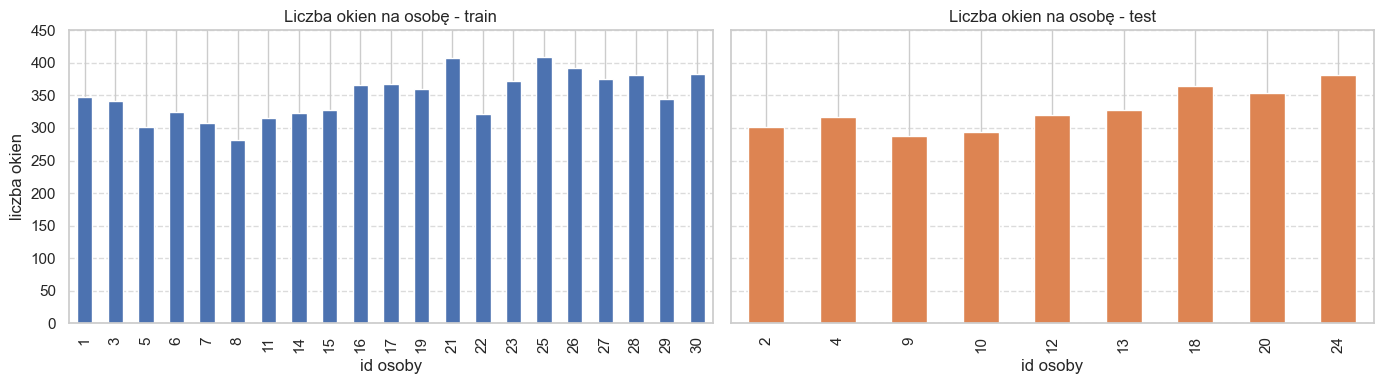

In [13]:
def windows_per_subject(groups, name):
    c = groups.value_counts().sort_index()
    print(f"[{name}]\tliczba osób: {c.shape[0]}")
    print(
        f"\t\tokna/osoba - średnia: {c.mean():.0f}, min: {c.min()}, max: {c.max()}, mediana: {c.median():.0f}"
    )
    return c


wps_train = windows_per_subject(groups_train, "train")
wps_test = windows_per_subject(groups_test, "test")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

wps_train.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Liczba okien na osobę - train")
axes[0].set_xlabel("id osoby")
axes[0].set_ylabel("liczba okien")

wps_test.plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Liczba okien na osobę - test")
axes[1].set_xlabel("id osoby")
axes[1].set_ylabel("liczba okien")

max_y = float(max(wps_train.max(), wps_test.max()))
max_y_rounded = math.ceil(max_y / 50) * 50

for ax in axes:
    ax.set_ylim(0, max_y_rounded)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
if FIGURES_DIR.exists():
    fig.savefig(
        FIGURES_DIR / "01_02_windows_per_subject.png", dpi=150, bbox_inches="tight"
    )
plt.show()

# 5. Rozkład klas per osoba

[train] osoby bez wszystkich 6 aktywności: 0
		0, czyli wszystkie osoby mają 6 aktywności.
[test] osoby bez wszystkich 6 aktywności: 0
		0, czyli wszystkie osoby mają 6 aktywności.


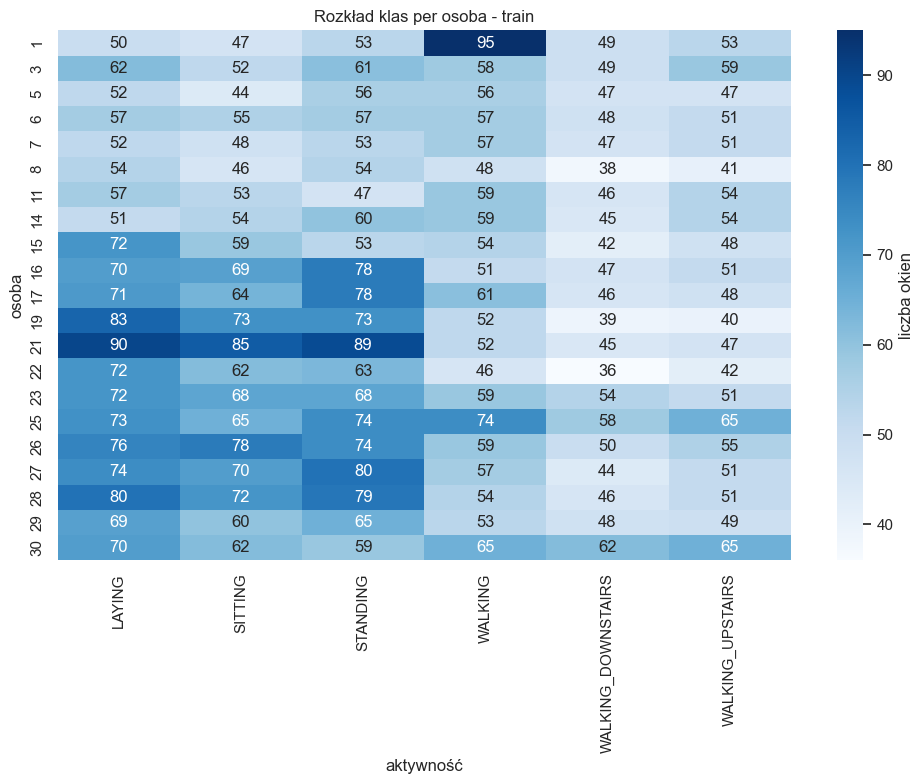

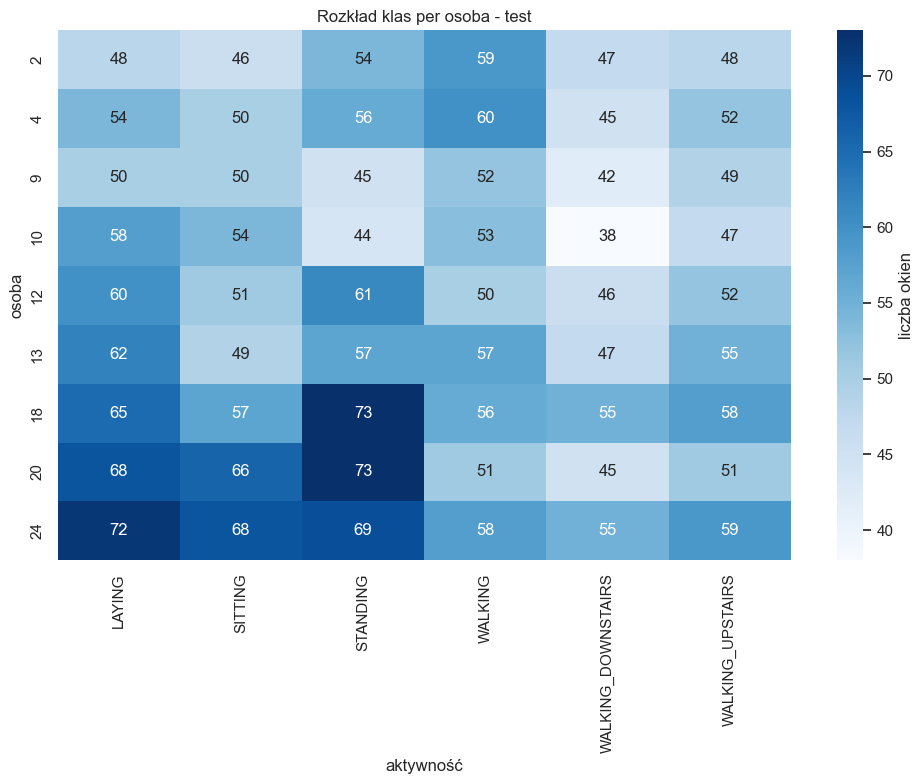

In [14]:
def class_per_subject(groups, y):
    df = pd.DataFrame({"subject": groups.values, "activity": y.values})
    return pd.crosstab(df["subject"], df["activity"])


def check_missing_classes(ct: pd.DataFrame, name: str):
    missing = ct[(ct == 0).any(axis=1)]
    print(f"[{name}] osoby bez wszystkich 6 aktywności: {len(missing)}")
    if len(missing):
        print(missing)
    else:
        print("\t\t0, czyli wszystkie osoby mają 6 aktywności.")
    return missing


def plot_class_per_subject(
    ct: pd.DataFrame,
    title: str,
    filename: str | None = None,
    figures_dir: Path | None = None,
):
    figure, axis = plt.subplots(figsize=(10, 8))

    if HAS_SEABORN:
        sns.heatmap(
            ct,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar_kws={"label": "liczba okien"},
            ax=axis,
        )
    else:
        print("Brak seaborn - nie można narysować heatmap.")
        return

    axis.set_title(title)
    axis.set_xlabel("aktywność")
    axis.set_ylabel("osoba")

    plt.tight_layout()

    if filename and figures_dir and figures_dir.exists():
        figure.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")

    plt.show()


ct_train = class_per_subject(groups_train, y_train)
ct_test = class_per_subject(groups_test, y_test)

check_missing_classes(ct_train, "train")
check_missing_classes(ct_test, "test")

plot_class_per_subject(
    ct_train,
    "Rozkład klas per osoba - train",
    "01_03_class_per_subject_train.png",
    FIGURES_DIR,
)

plot_class_per_subject(
    ct_test,
    "Rozkład klas per osoba - test",
    "01_04_class_per_subject_test.png",
    FIGURES_DIR,
)

# 5. Sprawdzenie wariancji cech

Zakres wartości cech [-1, 1]
Cechy dokładnie stałe (var = 0): 		0 / 561
Cechy prawie stałe (var < 0.0001): 		0 / 561


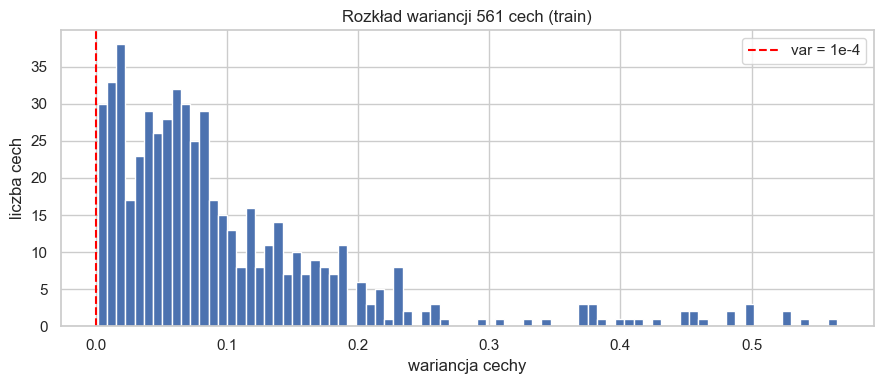

In [15]:
from sklearn.feature_selection import VarianceThreshold

# Ile cech jest stałych
vt0 = VarianceThreshold(threshold=0.0)
vt0.fit(X_train)
n_constant = np.logical_not(vt0.get_support()).sum()

# Ile cech jest prawie stałych
n_near_constant_threshold = 1e-4
vt_low = VarianceThreshold(threshold=n_near_constant_threshold)
vt_low.fit(X_train)
n_near_constant = np.logical_not(vt_low.get_support()).sum()

print("Zakres wartości cech [-1, 1]")
print(f"Cechy dokładnie stałe (var = 0): \t\t{n_constant} / {X_train.shape[1]}")
print(
    f"Cechy prawie stałe (var < {n_near_constant_threshold}): \t\t{n_near_constant} / {X_train.shape[1]}"
)

variances = X_train.var(axis=0)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(variances, bins=80, color="#4C72B0", edgecolor="white")
ax.axvline(n_near_constant_threshold, color="red", linestyle="--", label="var = 1e-4")
ax.set_xlabel("wariancja cechy")
ax.set_ylabel("liczba cech")
ax.set_title("Rozkład wariancji 561 cech (train)")
ax.legend()
plt.tight_layout()
if FIGURES_DIR.exists():
    fig.savefig(
        FIGURES_DIR / "01_05_feature_variance.png", dpi=150, bbox_inches="tight"
    )
plt.show()

# 6. Korelacje cech

Liczba par cech: 		157,080
Mediana |r|: 			0.381
Średnia |r|: 			0.419
Udział par |r| > 0.5   41.35%
Udział par |r| > 0.7   23.28%
Udział par |r| > 0.9    5.22%
Udział par |r| > 0.95   1.45%
Udział par |r| > 0.99   0.13%


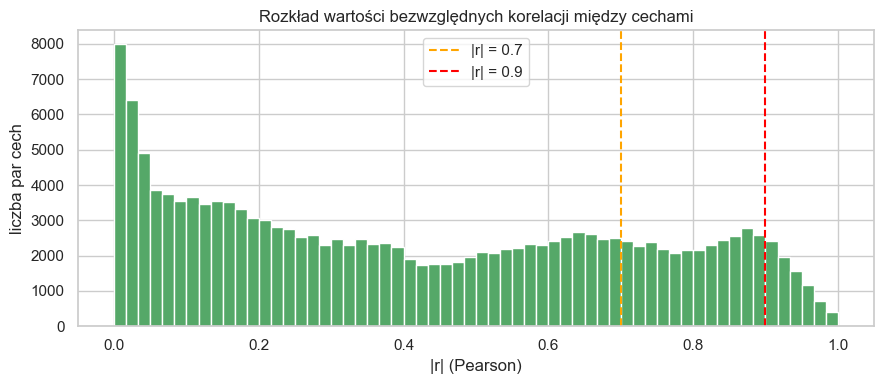

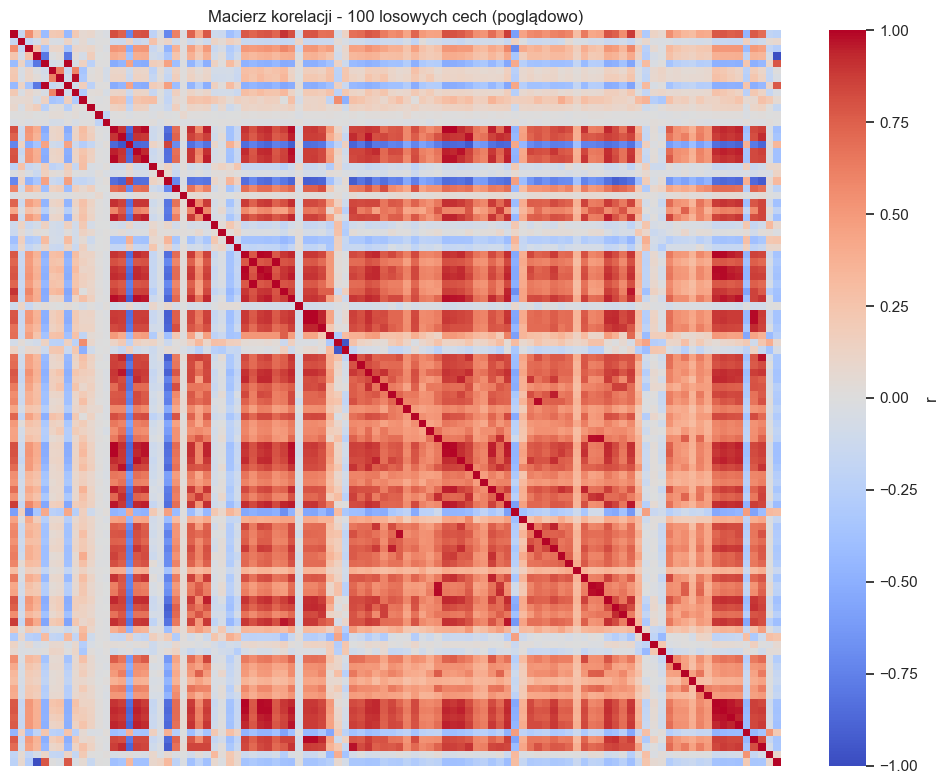

In [8]:
from utils.timer import Timer

with Timer("corr (pełna macierz 561x561)"):
    corr = X_train.corr().values

iu = np.triu_indices_from(corr, k=1)
abs_corr = np.abs(corr[iu])

print(f"Liczba par cech: \t\t{abs_corr.size:,}")
print(f"Mediana |r|: \t\t\t{np.median(abs_corr):.3f}")
print(f"Średnia |r|: \t\t\t{np.mean(abs_corr):.3f}")
for th in [0.5, 0.7, 0.9, 0.95, 0.99]:
    frac = (abs_corr > th).mean() * 100
    print(f"Udział par |r| > {th:<5} {frac:5.2f}%")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(abs_corr, bins=60, color="#55A868", edgecolor="white")
for th, c in zip([0.7, 0.9], ["orange", "red"]):
    ax.axvline(th, color=c, linestyle="--", label=f"|r| = {th}")
ax.set_xlabel("|r| (Pearson)")
ax.set_ylabel("liczba par cech")
ax.set_title("Rozkład wartości bezwzględnych korelacji między cechami")
ax.legend()
plt.tight_layout()
if FIGURES_DIR.exists():
    fig.savefig(FIGURES_DIR / "01_06_corr_abs_hist.png", dpi=150, bbox_inches="tight")
plt.show()

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = np.sort(rng.choice(X_train.shape[1], size=100, replace=False))

corr_sample = pd.DataFrame(
    corr[np.ix_(sample_idx, sample_idx)],
    index=[feature_names[i] for i in sample_idx],
    columns=[feature_names[i] for i in sample_idx],
)

fig, ax = plt.subplots(figsize=(10, 8))
if HAS_SEABORN:
    sns.heatmap(
        corr_sample,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"label": "r"},
        ax=ax,
    )
else:
    im = ax.imshow(corr_sample.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, label="r")
    ax.set_xticks([])
    ax.set_yticks([])
ax.set_title("Macierz korelacji - 100 losowych cech (poglądowo)")
plt.tight_layout()
if FIGURES_DIR.exists():
    fig.savefig(
        FIGURES_DIR / "01_07_corr_heatmap_sample.png", dpi=150, bbox_inches="tight"
    )
plt.show()